In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/BENALOUAN_BAHIJA_Dashboard_Agence_Marketing_Digital.csv")

In [6]:
df.shape

(3225, 19)

In [7]:
df.head()

,campaign_id,date,client,secteur,service,canal,impressions,clics,ctr_pct,conversions,budget_mad,revenu_mad,cpc_mad,cpa_mad,roas,score_seo,position_google,engagement_pct,statut_campagne
0,MKT-00001,2026-05-17,Client_021,Restaurant,Content,Influence,453741.0,3835.0,0.85,524.0,22239.15,1931520.19,5.80,42.44,86.85,60.4,12.6,1.83,Active
1,MKT-00002,2026-01-08,Client_017,Tourisme,Content,Influence,619139.0,8311.0,1.34,319.0,12484.77,536999.35,1.50,39.14,43.01,56.0,22.9,1.12,Terminée
2,MKT-00003,2026-05-21,Client_086,Santé,Landing page,Meta Ads,314615.0,4728.0,1.50,403.0,27175.66,1550536.65,5.75,67.43,57.06,72.3,25.1,2.77,Terminée
3,MKT-00004,2026-06-24,Client_012,Finance,Content,Influence,77078.0,662.0,0.86,58.0,23076.69,66841.26,34.86,397.87,2.90,44.9,21.6,8.85,Terminée
4,MKT-00005,2026-04-22,Client_078,Finance,SEO,LinkedIn Ads,729972.0,56899.0,7.79,928.0,38563.25,343941.02,0.68,41.56,8.92,50.9,29.9,6.73,Pause


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3225 entries, 0 to 3224
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   campaign_id      3225 non-null   object 
 1   date             3225 non-null   object 
 2   client           3225 non-null   object 
 3   secteur          3225 non-null   object 
 4   service          3225 non-null   object 
 5   canal            3225 non-null   object 
 6   impressions      3193 non-null   float64
 7   clics            3192 non-null   float64
 8   ctr_pct          3193 non-null   float64
 9   conversions      3193 non-null   float64
 10  budget_mad       3193 non-null   float64
 11  revenu_mad       3193 non-null   float64
 12  cpc_mad          3193 non-null   float64
 13  cpa_mad          3193 non-null   float64
 14  roas             3225 non-null   float64
 15  score_seo        3225 non-null   float64
 16  position_google  3225 non-null   float64
 17  engagement_pct

In [9]:
df.describe()

,impressions,clics,ctr_pct,conversions,budget_mad,revenu_mad,cpc_mad,cpa_mad,roas,score_seo,position_google,engagement_pct
count,3193.000000,3192.000000,3193.000000,3193.000000,3193.000000,3.193000e+03,3193.000000,3193.000000,3225.000000,3225.00000,3225.000000,3225.000000
mean,445858.243032,19992.310150,4.482549,1688.819292,22973.013273,3.794958e+06,5.217758,104.010949,435.253098,66.79076,15.738636,6.193823
std,259961.005177,16639.130622,2.333125,1818.276944,13040.076041,4.903192e+06,17.245138,603.186438,1656.444133,18.13954,8.448618,3.353613
min,1375.000000,27.000000,0.400000,0.000000,305.690000,0.000000e+00,0.010000,0.080000,0.000000,35.00000,1.000000,0.510000
25%,220509.000000,6044.500000,2.510000,374.000000,11533.330000,5.978249e+05,0.590000,7.010000,28.600000,51.40000,8.400000,3.240000
50%,441892.000000,15600.000000,4.470000,988.000000,23131.410000,1.890421e+06,1.310000,19.320000,97.290000,67.00000,16.000000,6.130000
75%,667213.000000,30522.000000,6.450000,2418.000000,34604.930000,5.105697e+06,3.590000,58.390000,310.520000,82.30000,23.100000,9.120000
max,899915.000000,75138.000000,8.500000,11955.000000,44995.010000,4.074488e+07,455.070000,27304.450000,39334.560000,98.00000,30.000000,12.000000


In [10]:
df.isnull().sum()

,0
campaign_id,0
date,0
client,0
secteur,0
service,0
canal,0
impressions,32
clics,33
ctr_pct,32
conversions,32


In [11]:
(df.isnull().sum() / len(df)) * 100  # Calculer le pourcentage de valeurs manquantes par colonne


,0
campaign_id,0.000000
date,0.000000
client,0.000000
secteur,0.000000
service,0.000000
canal,0.000000
impressions,0.992248
clics,1.023256
ctr_pct,0.992248
conversions,0.992248


In [12]:
df.duplicated().sum() # Compter le nombre de lignes dupliquées Pour éviter de compter plusieurs fois la même campagne.

np.int64(25)

In [13]:
# Transformer la colonne date en véritable format datetime
df["date"] = pd.to_datetime(df["date"])

In [14]:
df.info() # Vérifier que la colonne date est bien convertie

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3225 entries, 0 to 3224
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   campaign_id      3225 non-null   object        
 1   date             3225 non-null   datetime64[ns]
 2   client           3225 non-null   object        
 3   secteur          3225 non-null   object        
 4   service          3225 non-null   object        
 5   canal            3225 non-null   object        
 6   impressions      3193 non-null   float64       
 7   clics            3192 non-null   float64       
 8   ctr_pct          3193 non-null   float64       
 9   conversions      3193 non-null   float64       
 10  budget_mad       3193 non-null   float64       
 11  revenu_mad       3193 non-null   float64       
 12  cpc_mad          3193 non-null   float64       
 13  cpa_mad          3193 non-null   float64       
 14  roas             3225 non-null   float64

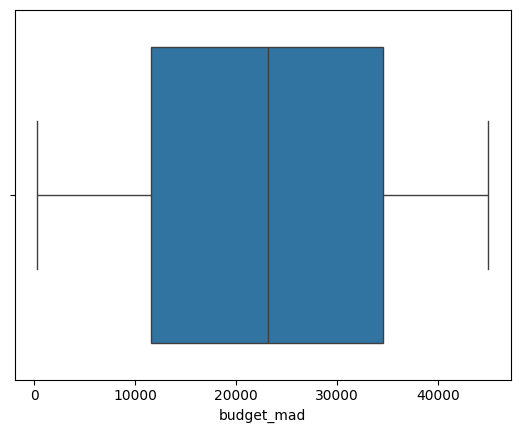

In [15]:
sns.boxplot(x=df["budget_mad"]) # Créer un graphique Boxplot pour analyser la distribution des budgets
plt.show()    #J'ai utilisé un Boxplot pour vérifier la présence de valeurs aberrantes dans les budgets.
              # L'analyse montre qu'aucune valeur extrême n'est présente,
              # ce qui indique une bonne cohérence des données avant le calcul des KPI et des visualisations.

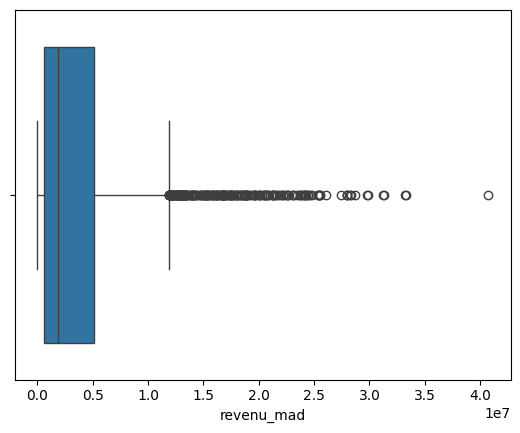

In [16]:
sns.boxplot(x=df["revenu_mad"])
plt.show() #Le Boxplot de la variable revenu_mad révèle la présence de nombreuses valeurs aberrantes situées au-dessus de la limite supérieure
# de la distribution. Cela indique que certaines campagnes ou certains clients génèrent des revenus nettement plus élevés que la majorité
#des observations. Ces valeurs peuvent correspondre à des campagnes exceptionnellement performantes ou nécessiter une vérification
# complémentaire afin d'écarter d'éventuelles erreurs de saisie.

In [17]:
num_cols = df.select_dtypes(include=np.number).columns # Sélectionner uniquement les colonnes contenant des nombres (int, float)
# Récupérer automatiquement les noms de toutes les colonnes numériques

In [18]:
# Parcourir toutes les colonnes numériques
for col in num_cols:

    # Remplacer les valeurs manquantes de chaque colonne par sa médiane.La médiane est moins sensible aux valeurs extrêmes que la moyenne.
    df[col] = df[col].fillna(df[col].median())

In [19]:
# Calculer le montant total investi
budget_total = df["budget_mad"].sum()

# Afficher le résultat
budget_total

np.float64(74093036.5)

In [20]:
revenu_total = df["revenu_mad"].sum()
revenu_total

np.float64(12177793633.45)

In [21]:
roas = revenu_total / budget_total #Pour 1 MAD investi, combien récupère-t-on ?
roas

np.float64(164.3581395594443)

In [22]:
df["ctr_pct"].mean() # Calculer le CTR moyen (Click Through Rate : taux de clic),
# c'est-à-dire le pourcentage moyen de personnes ayant cliqué
# sur une publicité après l'avoir vue

np.float64(4.48242480620155)

In [23]:
df["cpc_mad"].mean()

np.float64(5.1789829457364345)

In [24]:
# Calculer le coût moyen par acquisition (CPA),
# afin de connaître le coût moyen nécessaire pour obtenir un client
df["cpa_mad"].mean()

np.float64(103.17060465116279)

In [25]:
# Calculer le nombre total de conversions réalisées
df["conversions"].sum()

np.float64(5424016.0)

In [26]:
df["score_seo"].mean()

np.float64(66.79075968992248)

ANALYSE DU **MÉTIER**

In [27]:
# Regrouper les données par client et sélectionner la colonne revenu_mad
top_clients = (
    df.groupby("client")["revenu_mad"]

    # Calculer le revenu total généré par chaque client
    .sum()

    # Trier les clients du plus rentable au moins rentable
    .sort_values(ascending=False)

    # Afficher les 10 clients générant le plus de revenus
    .head(10)
)

# Afficher le résultat
top_clients

,revenu_mad
client,
Client_080,2.467639e+08
Client_044,2.110323e+08
Client_011,2.099416e+08
Client_053,1.991090e+08
Client_009,1.927047e+08
Client_066,1.924040e+08
Client_072,1.907554e+08
Client_058,1.904856e+08
Client_041,1.836218e+08


In [28]:
# Regrouper les campagnes par service,
# calculer le revenu total généré par chaque service,
# puis trier les résultats du plus rentable au moins rentable
df.groupby("service")["revenu_mad"] \
  .sum() \
  .sort_values(ascending=False)

,revenu_mad
service,
Publicité,2.204633e+09
Branding,2.150698e+09
Content,2.148278e+09
SEO,2.054758e+09
App mobile,1.941840e+09
Landing page,1.677587e+09


In [29]:
# Regrouper les données par canal marketing,
# calculer le ROAS moyen de chaque canal(Return On Advertising Spend),
# où ROAS = Revenu / Budget.
# Cet indicateur mesure la rentabilité des campagnes marketing
# et indique combien de MAD sont gagnés pour chaque 1 MAD investi.
# puis trier les canaux du meilleur au moins performant
df.groupby("canal")["roas"] \
  .mean() \
  .sort_values(ascending=False)

,roas
canal,
Emailing,490.915754
Influence,485.184624
LinkedIn Ads,471.600607
SEO,430.484012
Meta Ads,415.262608
Google Ads,401.033554
TikTok Ads,353.350216


ANALYSE **TEMPORELLE**

In [31]:
# Vérifier le type de la colonne date
print(df["date"].dtype)

datetime64[ns]


In [32]:
# Convertir la colonne date au format datetime
df["date"] = pd.to_datetime(df["date"])

In [34]:
# Créer une colonne mois (année-mois) Pour regrouper les campagnes du même mois.
df["mois"] = df["date"].dt.to_period("M")

In [35]:
# Transformer en texte pour faciliter l'affichage car les graphiques affichent mieux le txte
df["mois"] = df["mois"].astype(str)

In [37]:
# Regrouper les revenus par mois
revenu_mensuel = df.groupby("mois")["revenu_mad"].sum()
revenu_mensuel

,revenu_mad
mois,
2026-01,1.998832e+09
2026-02,1.899819e+09
2026-03,2.131525e+09
2026-04,2.161473e+09
2026-05,2.031684e+09
2026-06,1.954460e+09


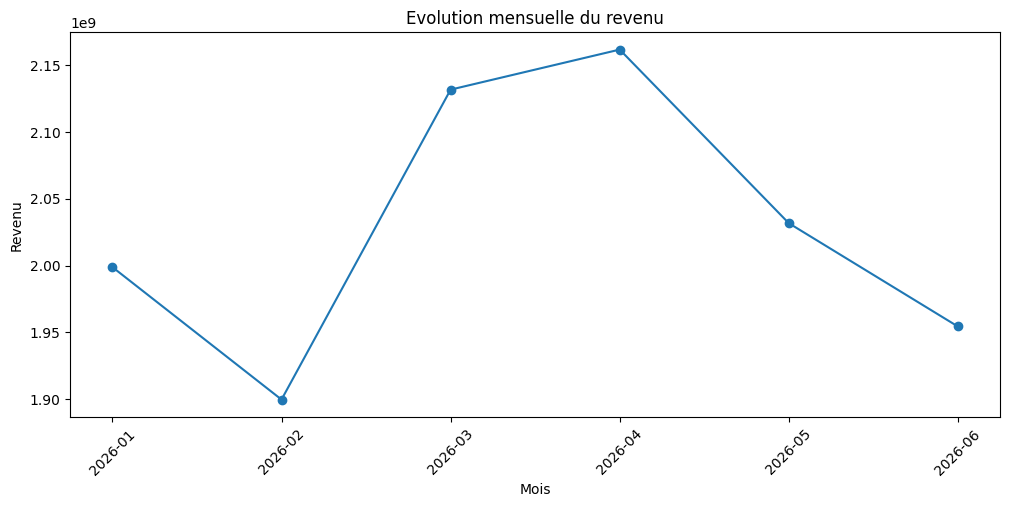

In [39]:
plt.figure(figsize=(12,5)) # Créer une zone de dessin de largeur 12 et hauteur 5 pour le graphique
# Tracer une courbe à partir des données


plt.plot(
    revenu_mensuel.index,    # Utiliser les mois comme valeurs de l'axe X (horizontal)
    revenu_mensuel.values,    # Utiliser les revenus comme valeurs de l'axe Y (vertical)
    marker="o"                   # Afficher un cercle sur chaque point de la courbe
)

plt.title("Evolution mensuelle du revenu")
plt.xlabel("Mois")
plt.ylabel("Revenu")
plt.xticks(rotation=45) # Incliner les labels de l'axe X à 45 degrés pour améliorer la lisibilité


plt.show()

**Comparaison par secteur**

In [41]:
# Regrouper les revenus par secteur
revenu_secteur = (
    df.groupby("secteur")["revenu_mad"]

    # Additionner les revenus de chaque secteur
    .sum()

    # Trier du plus rentable au moins rentable
    .sort_values(ascending=False)
)


revenu_secteur

,revenu_mad
secteur,
Restaurant,1.989380e+09
Finance,1.885651e+09
Tourisme,1.825285e+09
Retail,1.703662e+09
Santé,1.647226e+09
Immobilier,1.581630e+09
Education,1.544959e+09


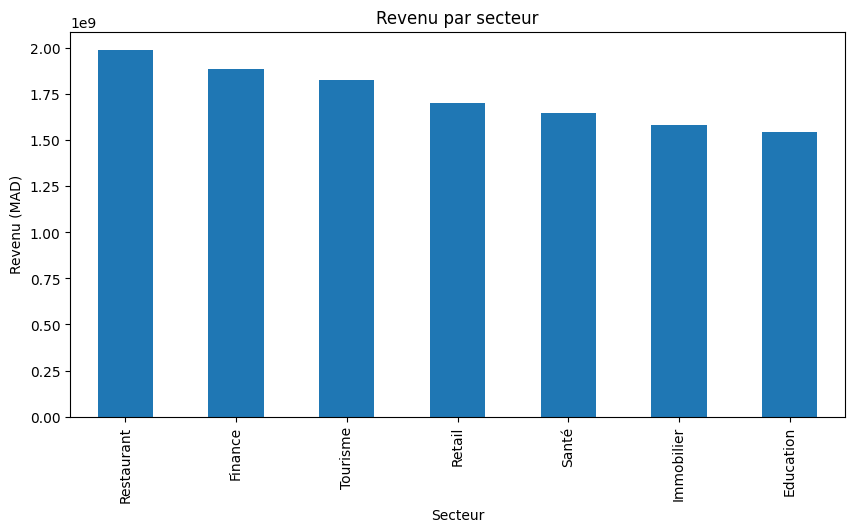

In [42]:

plt.figure(figsize=(10,5))
 # Créer un graphique en barres pour comparer les revenus entre les différents secteurs
 # Ce graphique permet d'identifier rapidement les secteurs les plus rentables et ceux qui génèrent le moins de revenus afin d'orienter les décisions marketing et les investissements futurs.
revenu_secteur.plot(kind="bar")

# Ajouter un titre
plt.title("Revenu par secteur")

# Nom de l'axe X
plt.xlabel("Secteur")

# Nom de l'axe Y
plt.ylabel("Revenu (MAD)")
plt.show()

**Comparaison par Service**

In [44]:
# Regrouper les revenus par service
revenu_service = (
    df.groupby("service")["revenu_mad"]

    # Calculer le revenu total de chaque service
    .sum()

    # Trier du plus rentable au moins rentable
    .sort_values(ascending=False)
)

# Afficher les résultats
revenu_service

,revenu_mad
service,
Publicité,2.204633e+09
Branding,2.150698e+09
Content,2.148278e+09
SEO,2.054758e+09
App mobile,1.941840e+09
Landing page,1.677587e+09


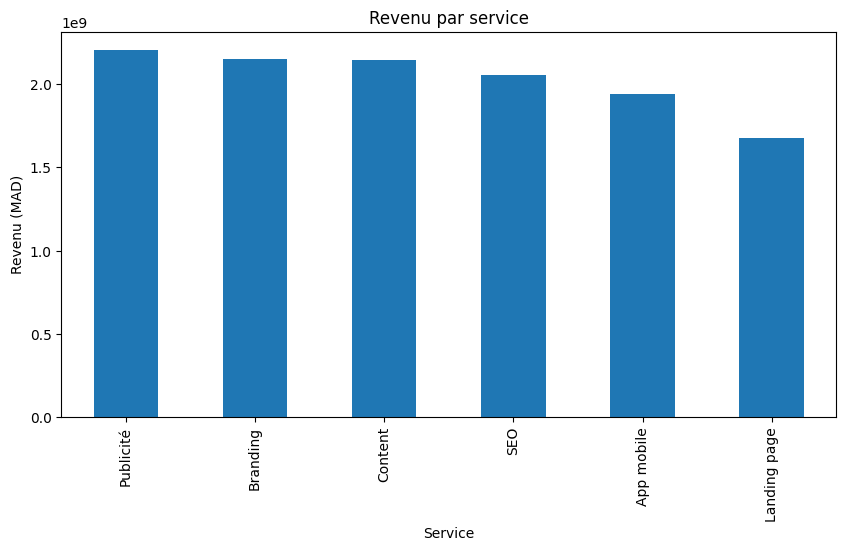

In [47]:

plt.figure(figsize=(10,5))

# Créer un graphique en barres
revenu_service.plot(kind="bar")

# Ajouter un titre
plt.title("Revenu par service")

# Ajouter le nom de l'axe X
plt.xlabel("Service")

# Ajouter le nom de l'axe Y
plt.ylabel("Revenu (MAD)")


plt.show()

**Comparaison par Canal**

In [46]:
# Regrouper les revenus par canal
revenu_canal = (
    df.groupby("canal")["revenu_mad"]

    # Calculer le revenu total par canal
    .sum()

    # Trier du plus rentable au moins rentable
    .sort_values(ascending=False)
)

revenu_canal

,revenu_mad
canal,
Meta Ads,1.860536e+09
SEO,1.837251e+09
Emailing,1.754751e+09
Influence,1.752236e+09
Google Ads,1.728336e+09
TikTok Ads,1.688663e+09
LinkedIn Ads,1.556021e+09


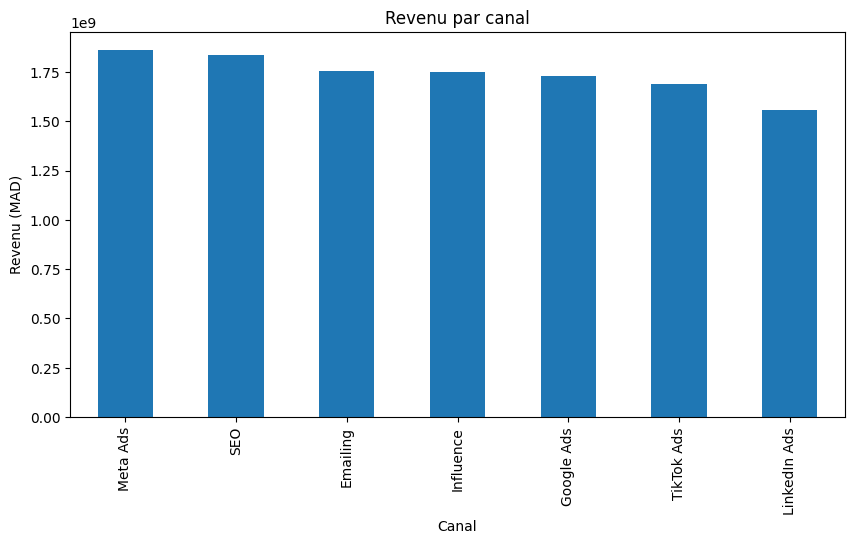

In [48]:

plt.figure(figsize=(10,5))
# Créer un graphique en barres
revenu_canal.plot(kind="bar")
plt.title("Revenu par canal")
plt.xlabel("Canal")
plt.ylabel("Revenu (MAD)")
plt.show()

**Analyse de rentabilité**

In [49]:
# Regrouper les campagnes selon le service
roas_service = (

    df.groupby("service")

    # Sélectionner uniquement la colonne ROAS
    ["roas"]

    # Calculer le ROAS moyen pour chaque service
    .mean()

    # Trier les services du plus rentable au moins rentable
    .sort_values(ascending=False)

)

# Afficher le résultat
roas_service

,roas
service,
App mobile,538.176282
Branding,525.696412
Publicité,473.088165
Content,426.105019
SEO,357.796190
Landing page,302.975814


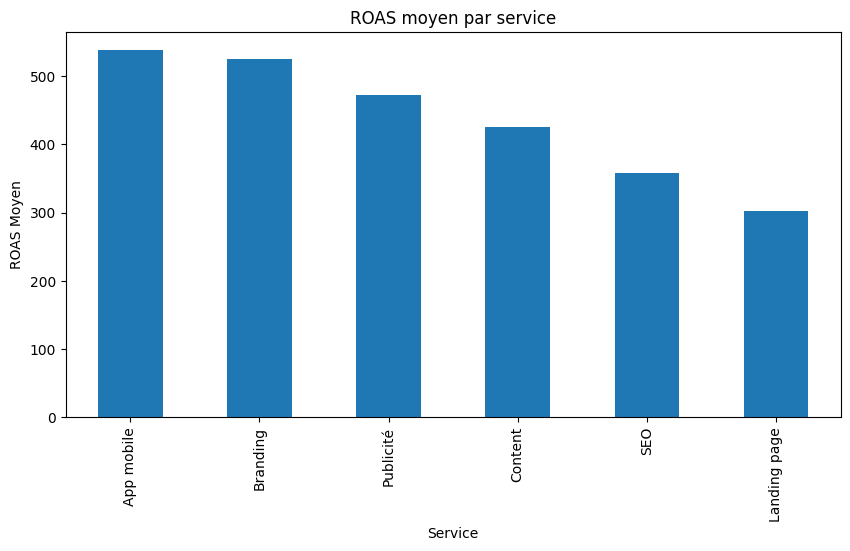

In [52]:
plt.figure(figsize=(10,5))

# Créer un graphique en barres
roas_service.plot(kind="bar")

plt.title("ROAS moyen par service")

plt.xlabel("Service")

plt.ylabel("ROAS Moyen")

plt.show() #Cette analyse permet d'identifier les services les plus rentables de l'agence.

#Le ROAS moyen est calculé pour chaque service afin de mesurer le revenu généré pour chaque dirham investi.

#Les services présentant le ROAS le plus élevé sont les plus performants et méritent davantage d'investissements.

**Scatter Plot Graphique de relation entre deux variables numériques importantes**

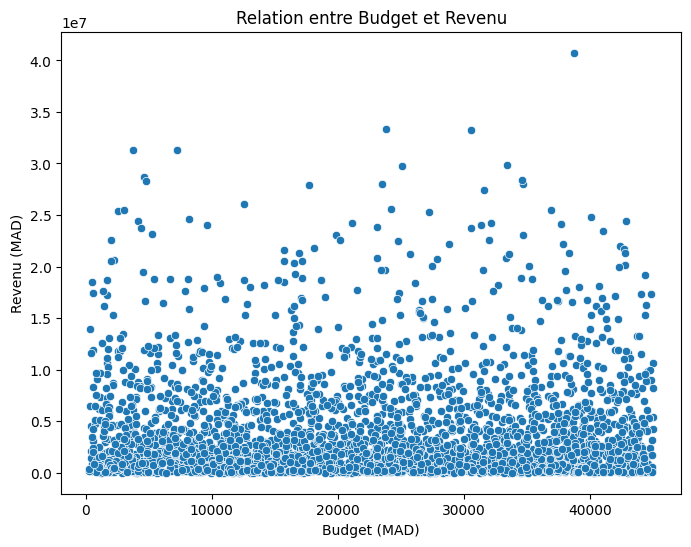

In [55]:
plt.figure(figsize=(8,6))

# Créer un graphique de dispersion
sns.scatterplot(

    # Utiliser le DataFrame df
    data=df,

    # Mettre le budget sur l'axe horizontal (X)
    x="budget_mad",

    # Mettre le revenu sur l'axe vertical (Y)
    y="revenu_mad"
)

plt.title("Relation entre Budget et Revenu")

plt.xlabel("Budget (MAD)")

plt.ylabel("Revenu (MAD)")

plt.show() #Cette visualisation permet d'étudier la relation entre le budget investi et le revenu généré.
#Chaque point représente une campagne marketing.
#Une tendance croissante indique qu'une augmentation du budget est généralement associée à une augmentation du revenu.

**Heatmap de corrélation pour comprendre les dépendances entre variables**

In [58]:
corr = df.select_dtypes(include=np.number).corr() # Calculer la corrélation entre toutes les colonnes numériques

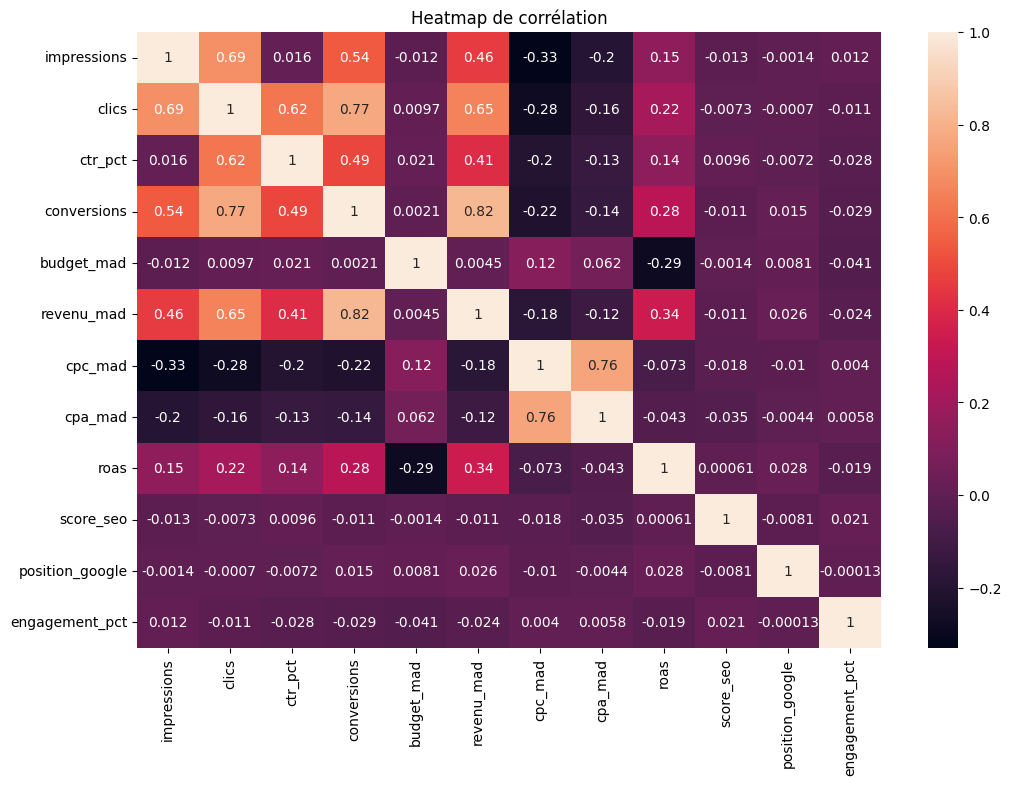

In [60]:
plt.figure(figsize=(12,8))

# Créer une heatmap avec les valeurs affichées
sns.heatmap(
    corr,
    annot=True
)
plt.title("Heatmap de corrélation")
plt.show()                             #Cette heatmap permet d'identifier les relations entre les différentes variables numériques du dataset.
                                       #Les valeurs proches de +1 indiquent une forte relation positive, tandis que les valeurs proches de -1 indiquent une forte relation négative.
                                       #Cette analyse aide à comprendre quels indicateurs évoluent ensemble et quels facteurs peuvent influencer la performance marketing.

**Conclusions métier**

# CONCLUSIONS METIER

1. Evolution temporelle
L'analyse temporelle montre l'évolution des revenus de l'agence au fil des mois. Les périodes de croissance et de baisse permettent d'identifier les moments les plus performants.

2. Analyse des clients
Les 10 meilleurs clients génèrent une part importante du revenu total. Ils représentent des clients stratégiques pour l'agence.

3. Analyse des services
Certains services contribuent davantage au chiffre d'affaires que d'autres. Ils constituent les activités les plus rentables.

4. Analyse des canaux
Les performances varient selon les canaux marketing utilisés. Les canaux les plus performants méritent davantage d'investissements.

5. Rentabilité
L'analyse du ROAS montre quels services offrent le meilleur retour sur investissement publicitaire.

6. Corrélations
La heatmap met en évidence les relations entre les indicateurs marketing tels que le budget, les revenus, les clics et les conversions.

